In [1]:

import tkinter as tk
from tkinter import ttk
from tkinter import messagebox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')
apps_df = pd.read_csv(r"C:\Users\DELL\Pictures\elevance_skills\play_store_data\apps.csv")
reviews_df = pd.read_csv(r"C:\Users\DELL\Pictures\elevance_skills\play_store_data\user_reviews.csv")



[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [5]:
# Step 1: Load the Dataset
apps_df = pd.read_csv(r"C:\Users\DELL\Pictures\elevance_skills\play_store_data\apps.csv")
reviews_df = pd.read_csv(r"C:\Users\DELL\Pictures\elevance_skills\play_store_data\user_reviews.csv")

In [6]:
# Step 2: Data Cleaning
apps_df = apps_df.dropna(subset=['Rating'])
for column in apps_df.columns:
    apps_df[column].fillna(apps_df[column].mode()[0], inplace=True)
apps_df.drop_duplicates(inplace=True)
apps_df = apps_df[apps_df['Rating'] <= 5]
reviews_df.dropna(subset=['Translated_Review'], inplace=True)

In [7]:
# Merge datasets on 'App' and handle non-matching apps
merged_df = pd.merge(apps_df, reviews_df, on='App', how='inner')

In [8]:
# Step 3: Data Transformation
apps_df['Reviews'] = apps_df['Reviews'].astype(int)
apps_df['Installs'] = apps_df['Installs'].str.replace(',', '').str.replace('+', '').astype(int)
apps_df['Price'] = apps_df['Price'].str.replace('$', '').astype(float)

In [15]:
def convert_size(size):
    if pd.isna(size):
        return np.nan

    size = str(size)

    if 'M' in size:
        return float(size.replace('M', ''))

    elif 'k' in size:
        return float(size.replace('k', '')) / 1024

    else:
        return np.nan

In [17]:
apps_df['Size'] = apps_df['Size'].apply(convert_size)

In [18]:
def rating_group(rating):
    if rating >= 4:
        return 'Top rated'
    elif rating >= 3:
        return 'Above average'
    elif rating >= 2:
        return 'Average'
    else:
        return 'Below average'

apps_df['Rating_Group'] = apps_df['Rating'].apply(rating_group)

In [19]:
apps_df['Revenue'] = apps_df['Price'] * apps_df['Installs']

In [20]:
# Sentiment Analysis
sia = SentimentIntensityAnalyzer()
reviews_df['Sentiment_Score'] = reviews_df['Translated_Review'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

In [21]:
# Extract year from 'Last Updated' and create 'Year' column
apps_df['Last Updated'] = pd.to_datetime(apps_df['Last Updated'], errors='coerce')
apps_df['Year'] = apps_df['Last Updated'].dt.year

In [23]:
pip install pandas numpy matplotlib seaborn scikit-learn nltk


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [27]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

C:\Users\DELL\AppData\Local\Temp\ipykernel_13412\4041216610.py:258: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_13412\4041216610.py:496: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_13412\4041216610.py:606: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_13412\4041216610.py:652: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `h

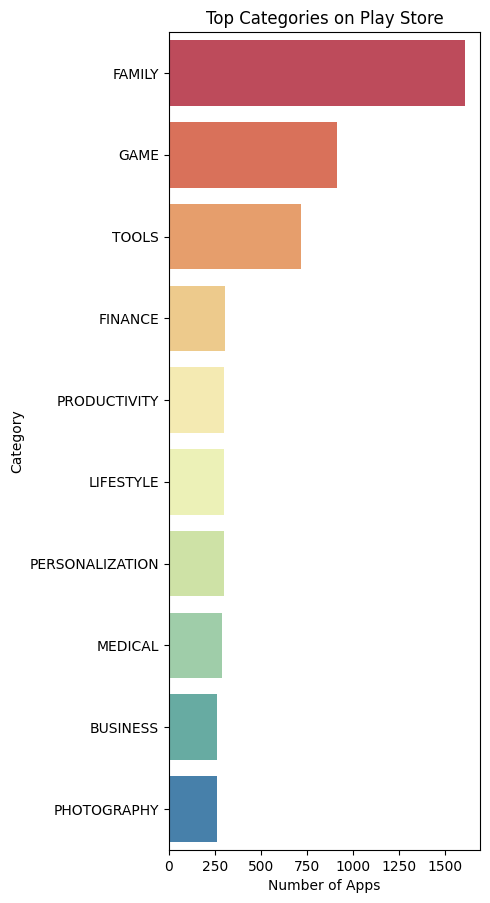

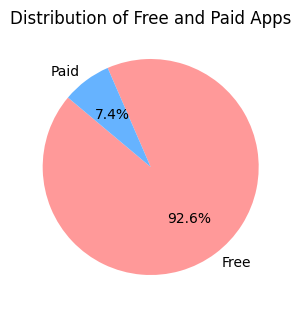

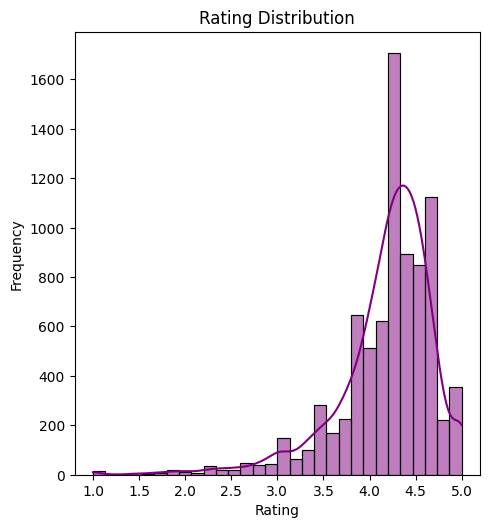

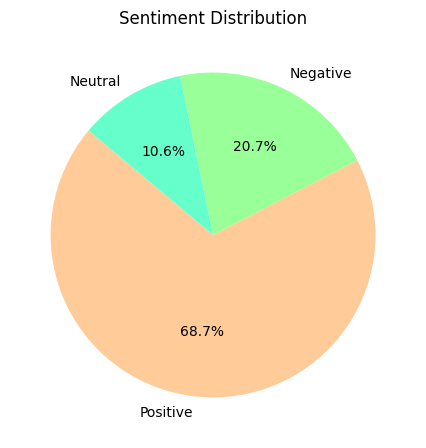

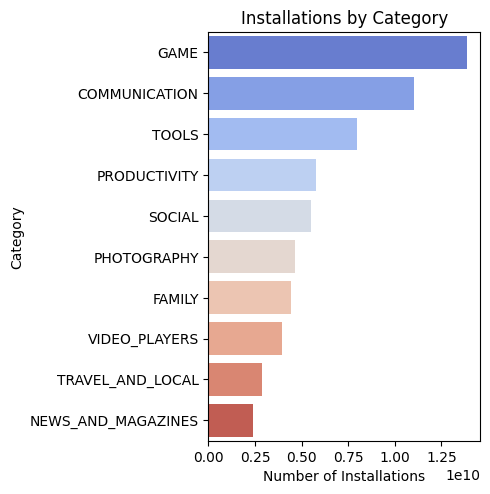

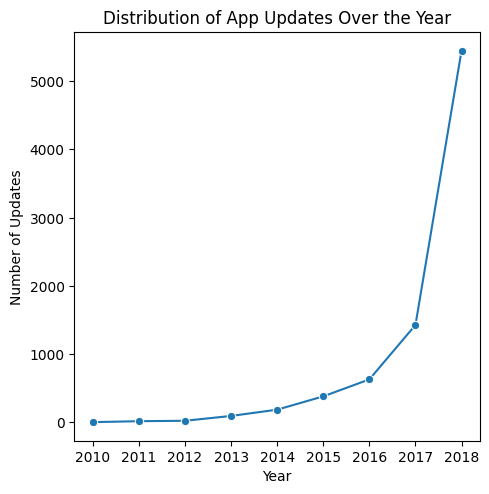

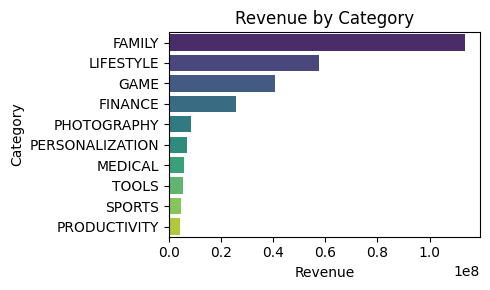

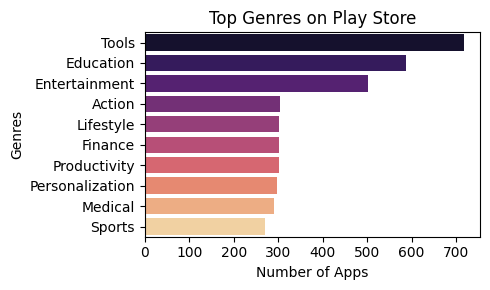

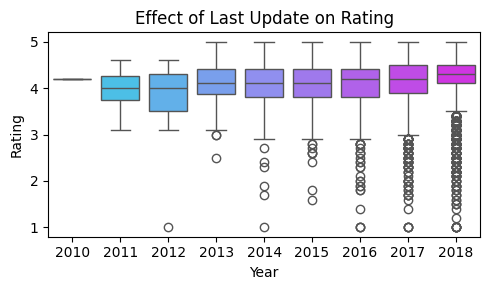

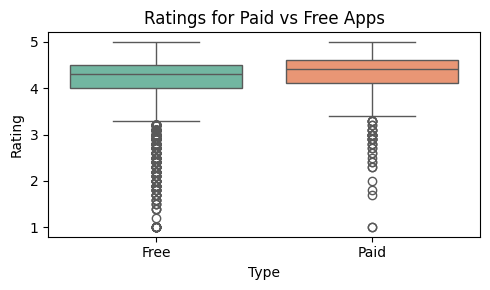

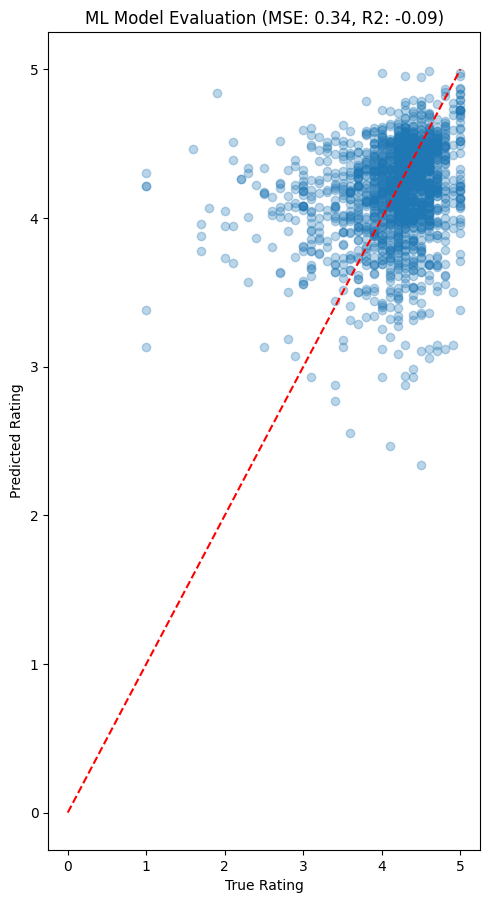

In [30]:
import tkinter as tk
from tkinter import ttk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon")


apps_df["Rating"] = pd.to_numeric(
    apps_df["Rating"],
    errors="coerce"
)

apps_df["Reviews"] = pd.to_numeric(
    apps_df["Reviews"],
    errors="coerce"
).fillna(0)

apps_df["Installs"] = (
    apps_df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

apps_df["Installs"] = pd.to_numeric(
    apps_df["Installs"],
    errors="coerce"
).fillna(0)

apps_df["Price"] = (
    apps_df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

apps_df["Price"] = pd.to_numeric(
    apps_df["Price"],
    errors="coerce"
).fillna(0)

apps_df["Last Updated"] = pd.to_datetime(
    apps_df["Last Updated"],
    errors="coerce"
)

apps_df["Year"] = apps_df["Last Updated"].dt.year

apps_df["Log_Reviews"] = np.log1p(
    apps_df["Reviews"]
)

apps_df["Log_Installs"] = np.log1p(
    apps_df["Installs"]
)

apps_df["Revenue"] = (
    apps_df["Price"] * apps_df["Installs"]
)

apps_df = apps_df.dropna(
    subset=["Rating"]
)

apps_df = apps_df[
    (apps_df["Rating"] >= 0) &
    (apps_df["Rating"] <= 5)
]

sia = SentimentIntensityAnalyzer()

if "Translated_Review" in reviews_df.columns:
    reviews_df["Translated_Review"] = (
        reviews_df["Translated_Review"]
        .fillna("")
        .astype(str)
    )

    reviews_df["Sentiment_Score"] = (
        reviews_df["Translated_Review"]
        .apply(
            lambda x: sia.polarity_scores(x)["compound"]
        )
    )
else:
    reviews_df["Sentiment_Score"] = 0


class AppDashboard(tk.Tk):

    def __init__(self):
        super().__init__()

        self.title(
            "Google Play Store Analysis Dashboard"
        )

        self.geometry("1200x800")

        self.configure(
            bg="lightgray"
        )

        main_frame = tk.Frame(
            self,
            bg="lightgray"
        )

        main_frame.pack(
            fill=tk.BOTH,
            expand=True
        )

        canvas = tk.Canvas(
            main_frame,
            bg="lightgray"
        )

        v_scrollbar = ttk.Scrollbar(
            main_frame,
            orient="vertical",
            command=canvas.yview
        )

        h_scrollbar = ttk.Scrollbar(
            main_frame,
            orient="horizontal",
            command=canvas.xview
        )

        v_scrollbar.pack(
            side="right",
            fill="y"
        )

        h_scrollbar.pack(
            side="bottom",
            fill="x"
        )

        canvas.pack(
            side="left",
            fill="both",
            expand=True
        )

        scrollable_frame = ttk.Frame(
            canvas
        )

        scrollable_frame.bind(
            "<Configure>",
            lambda e: canvas.configure(
                scrollregion=canvas.bbox("all")
            )
        )

        canvas.create_window(
            (0, 0),
            window=scrollable_frame,
            anchor="nw"
        )

        canvas.configure(
            yscrollcommand=v_scrollbar.set,
            xscrollcommand=h_scrollbar.set
        )

        for i in range(6):
            scrollable_frame.columnconfigure(
                i,
                weight=1
            )

        self.create_category_analysis(
            scrollable_frame,
            0,
            0
        )

        self.create_type_analysis(
            scrollable_frame,
            0,
            1
        )

        self.create_rating_sentiment_analysis(
            scrollable_frame,
            0,
            2
        )

        self.create_installation_update_analysis(
            scrollable_frame,
            0,
            3
        )

        self.create_additional_insights(
            scrollable_frame,
            0,
            4
        )

        self.create_ml_model_evaluation(
            scrollable_frame,
            0,
            5
        )

    def create_category_analysis(
        self,
        parent,
        row,
        column
    ):
        frame = ttk.Frame(
            parent,
            padding="5"
        )

        frame.grid(
            row=row,
            column=column,
            sticky="nsew",
            pady=5
        )

        frame.columnconfigure(
            0,
            weight=1
        )

        category_counts = (
            apps_df["Category"]
            .value_counts()
            .nlargest(10)
        )

        fig, ax = plt.subplots(
            figsize=(5, 3)
        )

        sns.barplot(
            x=category_counts.values,
            y=category_counts.index,
            palette="Spectral",
            ax=ax
        )

        ax.set_title(
            "Top Categories on Play Store"
        )

        ax.set_xlabel(
            "Number of Apps"
        )

        ax.set_ylabel(
            "Category"
        )

        fig.tight_layout()

        canvas = FigureCanvasTkAgg(
            fig,
            master=frame
        )

        canvas.draw()

        canvas.get_tk_widget().pack(
            expand=True,
            fill="both"
        )

    def create_type_analysis(
        self,
        parent,
        row,
        column
    ):
        frame = ttk.Frame(
            parent,
            padding="5"
        )

        frame.grid(
            row=row,
            column=column,
            sticky="nsew",
            pady=5
        )

        frame.columnconfigure(
            0,
            weight=1
        )

        type_counts = (
            apps_df["Type"]
            .value_counts()
        )

        fig, ax = plt.subplots(
            figsize=(3, 2)
        )

        ax.pie(
            type_counts,
            labels=type_counts.index,
            autopct="%1.1f%%",
            startangle=140,
            colors=[
                "#ff9999",
                "#66b3ff"
            ]
        )

        ax.set_title(
            "Distribution of Free and Paid Apps"
        )

        fig.tight_layout()

        canvas = FigureCanvasTkAgg(
            fig,
            master=frame
        )

        canvas.draw()

        canvas.get_tk_widget().pack(
            expand=True,
            fill="both"
        )

    def create_rating_sentiment_analysis(
        self,
        parent,
        row,
        column
    ):
        frame = ttk.Frame(
            parent,
            padding="5"
        )

        frame.grid(
            row=row,
            column=column,
            sticky="nsew",
            pady=5
        )

        frame.columnconfigure(
            0,
            weight=1
        )

        fig, ax = plt.subplots(
            figsize=(5, 3)
        )

        sns.histplot(
            apps_df["Rating"],
            bins=30,
            kde=True,
            color="purple",
            ax=ax
        )

        ax.set_title(
            "Rating Distribution"
        )

        ax.set_xlabel(
            "Rating"
        )

        ax.set_ylabel(
            "Frequency"
        )

        fig.tight_layout()

        canvas = FigureCanvasTkAgg(
            fig,
            master=frame
        )

        canvas.draw()

        canvas.get_tk_widget().pack(
            expand=True,
            fill="both"
        )

        sentiment_counts = (
            reviews_df["Sentiment_Score"]
            .apply(
                lambda x:
                "Positive"
                if x > 0
                else (
                    "Negative"
                    if x < 0
                    else "Neutral"
                )
            )
            .value_counts()
        )

        fig, ax = plt.subplots(
            figsize=(3, 2)
        )

        ax.pie(
            sentiment_counts,
            labels=sentiment_counts.index,
            autopct="%1.1f%%",
            startangle=140,
            colors=[
                "#ffcc99",
                "#99ff99",
                "#66ffcc"
            ]
        )

        ax.set_title(
            "Sentiment Distribution"
        )

        fig.tight_layout()

        canvas = FigureCanvasTkAgg(
            fig,
            master=frame
        )

        canvas.draw()

        canvas.get_tk_widget().pack(
            expand=True,
            fill="both"
        )

    def create_installation_update_analysis(
        self,
        parent,
        row,
        column
    ):
        frame = ttk.Frame(
            parent,
            padding="5"
        )

        frame.grid(
            row=row,
            column=column,
            sticky="nsew",
            pady=5
        )

        frame.columnconfigure(
            0,
            weight=1
        )

        installs_by_category = (
            apps_df
            .groupby("Category")["Installs"]
            .sum()
            .nlargest(10)
        )

        fig, ax = plt.subplots(
            figsize=(5, 3)
        )

        sns.barplot(
            x=installs_by_category.values,
            y=installs_by_category.index,
            palette="coolwarm",
            ax=ax
        )

        ax.set_title(
            "Installations by Category"
        )

        ax.set_xlabel(
            "Number of Installations"
        )

        ax.set_ylabel(
            "Category"
        )

        fig.tight_layout()

        canvas = FigureCanvasTkAgg(
            fig,
            master=frame
        )

        canvas.draw()

        canvas.get_tk_widget().pack(
            expand=True,
            fill="both"
        )

        updates_over_year = (
            apps_df["Year"]
            .value_counts()
            .sort_index()
        )

        fig, ax = plt.subplots(
            figsize=(5, 3)
        )

        sns.lineplot(
            x=updates_over_year.index,
            y=updates_over_year.values,
            marker="o",
            ax=ax
        )

        ax.set_title(
            "Distribution of App Updates Over the Year"
        )

        ax.set_xlabel(
            "Year"
        )

        ax.set_ylabel(
            "Number of Updates"
        )

        fig.tight_layout()

        canvas = FigureCanvasTkAgg(
            fig,
            master=frame
        )

        canvas.draw()

        canvas.get_tk_widget().pack(
            expand=True,
            fill="both"
        )

    def create_additional_insights(
        self,
        parent,
        row,
        column
    ):
        frame = ttk.Frame(
            parent,
            padding="5"
        )

        frame.grid(
            row=row,
            column=column,
            sticky="nsew",
            pady=5
        )

        frame.columnconfigure(
            0,
            weight=1
        )

        revenue_by_category = (
            apps_df
            .groupby("Category")["Revenue"]
            .sum()
            .nlargest(10)
        )

        fig, ax = plt.subplots(
            figsize=(5, 3)
        )

        sns.barplot(
            x=revenue_by_category.values,
            y=revenue_by_category.index,
            palette="viridis",
            ax=ax
        )

        ax.set_title(
            "Revenue by Category"
        )

        ax.set_xlabel(
            "Revenue"
        )

        ax.set_ylabel(
            "Category"
        )

        fig.tight_layout()

        canvas = FigureCanvasTkAgg(
            fig,
            master=frame
        )

        canvas.draw()

        canvas.get_tk_widget().pack(
            expand=True,
            fill="both"
        )

        genres_counts = (
            apps_df["Genres"]
            .fillna("")
            .str.split(";")
            .explode()
            .value_counts()
            .nlargest(10)
        )

        fig, ax = plt.subplots(
            figsize=(5, 3)
        )

        sns.barplot(
            x=genres_counts.values,
            y=genres_counts.index,
            palette="magma",
            ax=ax
        )

        ax.set_title(
            "Top Genres on Play Store"
        )

        ax.set_xlabel(
            "Number of Apps"
        )

        ax.set_ylabel(
            "Genres"
        )

        fig.tight_layout()

        canvas = FigureCanvasTkAgg(
            fig,
            master=frame
        )

        canvas.draw()

        canvas.get_tk_widget().pack(
            expand=True,
            fill="both"
        )

        fig, ax = plt.subplots(
            figsize=(5, 3)
        )

        sns.boxplot(
            data=apps_df,
            x="Year",
            y="Rating",
            palette="cool",
            ax=ax
        )

        ax.set_title(
            "Effect of Last Update on Rating"
        )

        ax.set_xlabel(
            "Year"
        )

        ax.set_ylabel(
            "Rating"
        )

        fig.tight_layout()

        canvas = FigureCanvasTkAgg(
            fig,
            master=frame
        )

        canvas.draw()

        canvas.get_tk_widget().pack(
            expand=True,
            fill="both"
        )

        fig, ax = plt.subplots(
            figsize=(5, 3)
        )

        sns.boxplot(
            data=apps_df,
            x="Type",
            y="Rating",
            palette="Set2",
            ax=ax
        )

        ax.set_title(
            "Ratings for Paid vs Free Apps"
        )

        ax.set_xlabel(
            "Type"
        )

        ax.set_ylabel(
            "Rating"
        )

        fig.tight_layout()

        canvas = FigureCanvasTkAgg(
            fig,
            master=frame
        )

        canvas.draw()

        canvas.get_tk_widget().pack(
            expand=True,
            fill="both"
        )

    def create_ml_model_evaluation(
        self,
        parent,
        row,
        column
    ):
        frame = ttk.Frame(
            parent,
            padding="5"
        )

        frame.grid(
            row=row,
            column=column,
            sticky="nsew",
            pady=5
        )

        frame.columnconfigure(
            0,
            weight=1
        )

        apps_df["Reviews"] = pd.to_numeric(
            apps_df["Reviews"],
            errors="coerce"
        ).fillna(0)

        apps_df["Installs"] = (
            apps_df["Installs"]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("+", "", regex=False)
        )

        apps_df["Installs"] = pd.to_numeric(
            apps_df["Installs"],
            errors="coerce"
        ).fillna(0)

        apps_df["Price"] = (
            apps_df["Price"]
            .astype(str)
            .str.replace("$", "", regex=False)
        )

        apps_df["Price"] = pd.to_numeric(
            apps_df["Price"],
            errors="coerce"
        ).fillna(0)

        apps_df["Log_Reviews"] = np.log1p(
            apps_df["Reviews"]
        )

        apps_df["Log_Installs"] = np.log1p(
            apps_df["Installs"]
        )

        ml_data = apps_df[
            [
                "Log_Reviews",
                "Log_Installs",
                "Price",
                "Rating"
            ]
        ].dropna()

        X = ml_data[
            [
                "Log_Reviews",
                "Log_Installs",
                "Price"
            ]
        ]

        y = ml_data["Rating"]

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42
        )

        model = RandomForestRegressor(
            n_estimators=100,
            random_state=42
        )

        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )

        mse = mean_squared_error(
            y_test,
            y_pred
        )

        r2 = r2_score(
            y_test,
            y_pred
        )

        fig, ax = plt.subplots(
            figsize=(5, 3)
        )

        ax.scatter(
            y_test,
            y_pred,
            alpha=0.3
        )

        ax.plot(
            [0, 5],
            [0, 5],
            "r--"
        )

        ax.set_title(
            f"ML Model Evaluation (MSE: {mse:.2f}, R2: {r2:.2f})"
        )

        ax.set_xlabel(
            "True Rating"
        )

        ax.set_ylabel(
            "Predicted Rating"
        )

        fig.tight_layout()

        canvas = FigureCanvasTkAgg(
            fig,
            master=frame
        )

        canvas.draw()

        canvas.get_tk_widget().pack(
            expand=True,
            fill="both"
        )


if __name__ == "__main__":
    app = AppDashboard()
    app.mainloop()